First, I import the libraries needed for the analysis. 
NumPy and pandas are used for handling and working with the data, 
while matplotlib is used to create visualisations.

I also import DstApi, which allows me to retrieve data directly from Statistics Denmark.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dstapi import DstApi

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Accessing the data from Statistics Denmark

In [2]:
IFOR41 = DstApi('IFOR41')

Exploring the available variables.

In [3]:
IFOR41.variable_levels('ULLIG', language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


Before selecting the data, we examine the available values for the municipality variable. Since the analysis is for all of Denmark we wil filter this out later, so it is not for individual municipalities

In [4]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


Here, we define which data we want to retrieve from Statistics Denmark. we select the Gini coefficient for all of Denmark and all available years.

In [5]:
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

We now retrieve the selected data and display the first rows to check that it was downloaded correctly.

In [6]:
gini = IFOR41.get_data(params=params)

gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


The below cell gives us an overview of the gini

In [7]:
gini.describe()

,TID
count,38.000000
mean,2005.500000
std,11.113055
min,1987.000000
25%,1996.250000
50%,2005.500000
75%,2014.750000
max,2024.000000


Cleaning the data by changing the gini to a float

In [8]:
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

Further clean up of the data by removing unnecessary columns and renaming the remaining ones for clarity.

In [9]:
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

Overview

In [10]:
gini.head()

,year,gini
0,2016,28.97
1,1999,23.83
2,1988,22.06
3,2015,28.77
4,1989,21.93


We can see that the years is not sorted, so we will sort the years in ascending order.

In [11]:
gini = gini.sort_values('year')

Checking

In [12]:
gini.head()

,year,gini
16,1987,22.07
2,1988,22.06
4,1989,21.93
30,1990,22.16
25,1991,21.99


The data is now as we wished with the wears in ascending order and we can now make a figure showing us the gini coefficient in Denmark over time. We have that gini is the name of our dataframe.

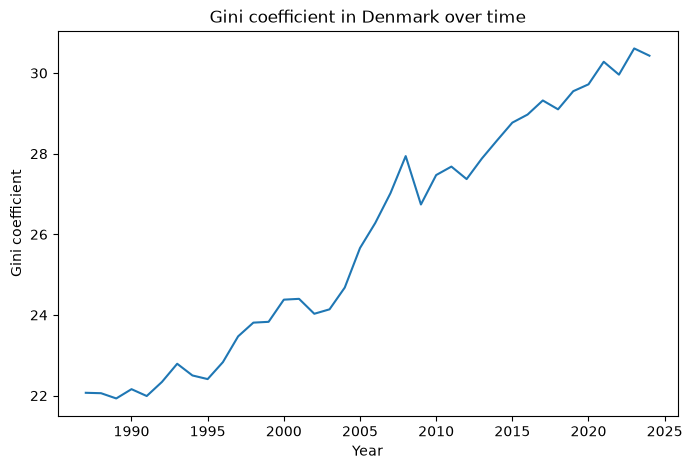

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gini['year'], gini['gini'])

ax.set_title('Gini coefficient in Denmark over time')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

plt.show()

We now move on the second part of question 1.1. We wish to see the share of income going to the richest 10 percent.

We make a connection to IFOR32, and have from the begining of this notebook already downloadet the necessary stuff.

In [14]:
IFOR32 = DstApi('IFOR32')

Here we get an overview of the table, and set the language to english

In [15]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [16]:
IFOR32.variable_levels('DECILGEN', language='en')

,id,text
0,1DC,First decil
1,2DC,Second decil
2,3DC,Third decil
3,4DC,Fourth decil
4,5DC,Fifth decil
5,6DC,Sixth decil
6,7DC,Seventh decil
7,8DC,Eigth decil
8,9DC,Ninth decil
9,10DC,Tenth decil


We now specify the data we want from IFOR32. We select all ten income deciles, all years, and All Denmark.

Having problems with the decil mapping, We will fetch the dataset again to start fresh.

In [17]:


params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

income = IFOR32.get_data(params=params)

income.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [ ]:
#Makes the dataset ready

income['INDHOLD'] = income['INDHOLD'].astype(float)

income = income.drop(columns=['KOMMUNEDK'])

income = income.rename(columns={
    'DECILGEN': 'decil',
    'TID': 'year',
    'INDHOLD': 'income'
})

income.head()

#hi

,decil,year,income
0,First decil,2013,75704.0
1,Second decil,2013,140049.0
2,Third decil,2013,163582.0
3,Fourth decil,2013,185931.0
4,Fifth decil,2013,209384.0


In [19]:
# Makes the decils to numbers from 1 to 10

decil_map = {
    'First decil': 1,
    'Second decil': 2,
    'Third decil': 3,
    'Fourth decil': 4,
    'Fifth decil': 5,
    'Sixth decil': 6,
    'Seventh decil': 7,
    'Eighth decil': 8,
    'Ninth decil': 9,
    'Tenth decil': 10
}

income['decil'] = income['decil'].map(decil_map)

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0
267,NaN,1987,110184.0


In [20]:
# Fixing the missing 8th decil

income.loc[income['decil'].isna(), 'decil'] = 8

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
267,8.0,1987,110184.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0


The data have now been cleaned, and is ready for an analysis

In [21]:

income.groupby('decil')['income'].mean()

decil
1.0      63079.421053
2.0     115863.105263
3.0     135364.131579
4.0     153987.868421
5.0     172573.789474
6.0     191304.500000
7.0     211895.736842
8.0     237253.973684
9.0     274808.763158
10.0    443505.631579
Name: income, dtype: float64

Will now make a figure over the development of the decil groups over the years.

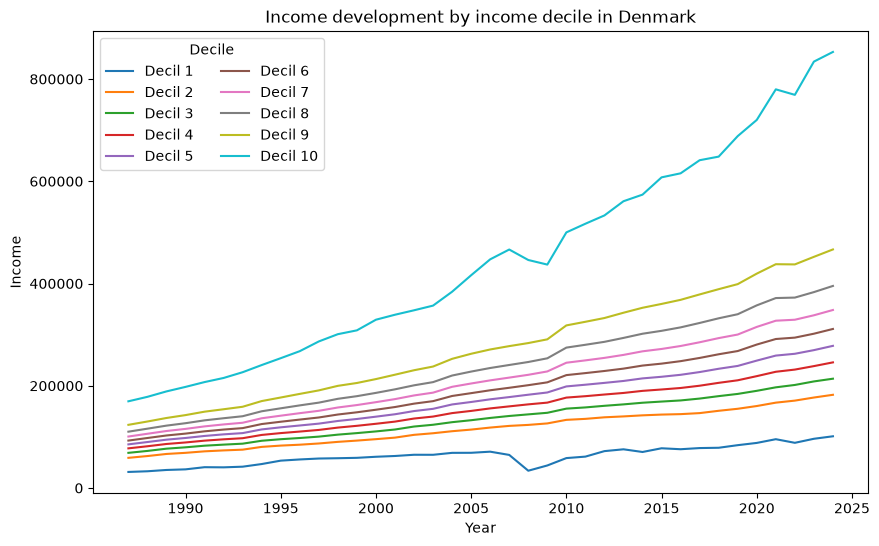

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

for decil in range(1, 11):
    data = income[income['decil'] == decil]
    ax.plot(data['year'], data['income'], label=f'Decil {decil}')

ax.set_title('Income development by income decile in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income')
ax.legend(title='Decile', ncol=2)

plt.show()

Will now make a further analysis to see the share of total income going to the richest 10%.

In [23]:
top10 = income[income['decil'] == 10].copy()

total_income = income.groupby('year')['income'].sum()

top10['top10_share'] = top10['income'] / top10['year'].map(total_income)

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,0.184549
117,10.0,1988,178357.0,0.184289
349,10.0,1989,188967.0,0.184952
189,10.0,1990,197793.0,0.186415
179,10.0,1991,207208.0,0.186683


Makes it into percent

In [24]:
top10['top10_share'] = top10['top10_share'] * 100

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,18.454866
117,10.0,1988,178357.0,18.428870
349,10.0,1989,188967.0,18.495170
189,10.0,1990,197793.0,18.641480
179,10.0,1991,207208.0,18.668346


Plot the share of total income received by the richest 10% over time.

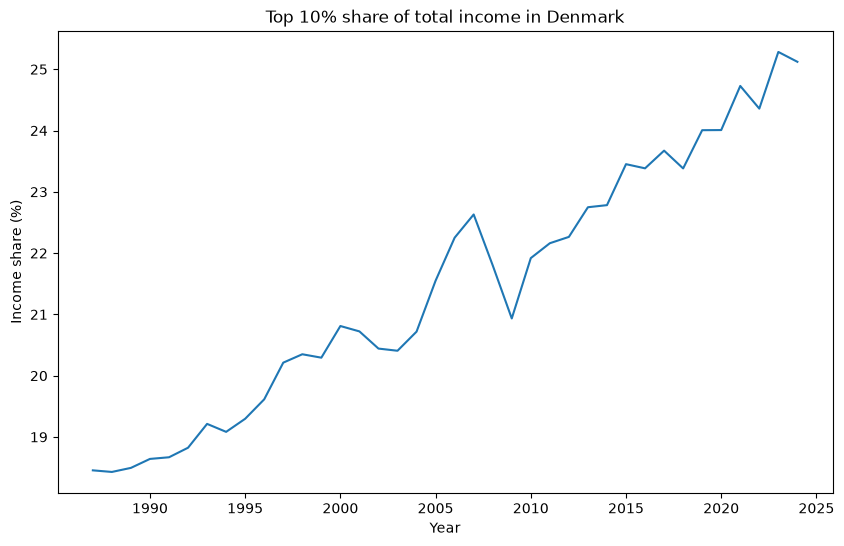

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(top10['year'], top10['top10_share'])

ax.set_title('Top 10% share of total income in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income share (%)')

plt.show()

Computes the correlation of our two results 

In [26]:
analysis = pd.merge(
    gini[['year', 'gini']],
    top10[['year', 'top10_share']],
    on='year',
    validate='1:1'
)

analysis['top10_share'] = analysis['top10_share'] * 100

analysis.corr()

,year,gini,top10_share
year,1.000000,0.985228,0.982948
gini,0.985228,1.000000,0.981642
top10_share,0.982948,0.981642,1.000000


The two measures tell a very similar story about inequality in Denmark. Both measures show an overall increase in inequality since 1987, although there are some fluctuations over time. We can see that the correlation between them is 0.981642, which is very close to a perfect correlation of 1.

Opgave 1.2

We define t as the number of years since 1987

In [27]:
gini['t'] = gini['year'] - 1987

gini.head()

,year,gini,t
16,1987,22.07,0
2,1988,22.06,1
4,1989,21.93,2
30,1990,22.16,3
25,1991,21.99,4


We import the function to be able to minimize

In [31]:
from scipy.optimize import minimize

We make the objective function

In [32]:
# Sum of squared errors
def objective(beta, t, y):
    predictions = sum(beta[k] * t**k for k in range(len(beta)))
    errors = y - predictions
    return np.sum(errors**2)

We convert the colums from out panda data frame to Numpy-arrays, so they are easier to use for optimazation

In [33]:
t = gini['t'].to_numpy()
y = gini['gini'].to_numpy()

Linear trend model

The linear trendmodel looks like this:

$$
\widehat{Gini} = \hat{\beta}_0 + \hat{\beta}_1 t
$$

The linear trend model has to parameters, that we in the following give some startvalues. The algorythm starts with zero, and thereafter we give different values to research, what values of the parameters minimizes the sum of the error (meaning the difference between the actual Gini and the models prediction).

In [35]:
initial_beta_linear = np.zeros(2)

linear_result = minimize(
    objective,
    initial_beta_linear,
    args=(t, y)
)

beta_linear = linear_result.x

beta_linear

array([21.04275355,  0.26354959])

In [36]:
print('Linear trend:')
print('beta_0 =', beta_linear[0])
print('beta_1 =', beta_linear[1])

Linear trend:
beta_0 = 21.04275354585798
beta_1 = 0.26354959467211453


The estimated linear model is

In [37]:
from IPython.display import display, Math

display(Math(
    rf'\widehat{{Gini}}_t = {beta_linear[0]:.3f} + {beta_linear[1]:.3f}t'
))

<IPython.core.display.Math object>

We compare the result with np.polyfit and see that it is the same

In [52]:
polyfit_linear = np.polyfit(t, y, 1)[::-1]

print('Minimize:', beta_linear)
print('Polyfit: ', polyfit_linear)

Minimize: [21.04275355  0.26354959]
Polyfit:  [21.04275304  0.26354962]


Quadratic trend

$$
\widehat{Gini} = \beta_0 + \beta_1 t + \beta_2 t^2
$$

We do the same now, but the model now has 3 parameters:

$$
\beta_0, \beta_1, \beta_2
$$

We define the quadratic function

In [42]:

def objective(beta, t, y):
    predictions = sum(beta[k] * t**k for k in range(len(beta)))
    errors = y - predictions
    return np.sum(errors**2)

We find the parameters that minimize the difference between the actual Gini and the model with minimize

In [47]:
initial_beta_quadratic = np.zeros(3)

quadratic_result = minimize(
    objective,
    initial_beta_quadratic,
    args=(t, y)
)

beta_quadratic = quadratic_result.x

We view the results and compare with np.polyfit

In [44]:
polyfit_quadratic = np.polyfit(t, y, 2)[::-1]

print('Minimize:', beta_quadratic)
print('Polyfit: ', polyfit_quadratic)

Minimize: [2.13041876e+01 2.19976262e-01 1.17765925e-03]
Polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]


The result with the two different methods are the same. The estimated quadratic function therefor is:

$$
\widehat{Gini}
=
21.3042
+
0.21998t
+
0.001178t^2
$$

Ginicoefficient in 2030 and 2040

We first define what t in 2030 and 2040 is

In [53]:
t_2030 = 2030 - 1987
t_2040 = 2040 - 1987

print(t_2030)
print(t_2040)

43
53


We insert the t-values in out models to view what the Ginicoefficient in the future is:

Linear:

In [55]:
gini_2030_linear = (
    beta_linear[0]
    + beta_linear[1] * t_2030
)

gini_2040_linear = (
    beta_linear[0]
    + beta_linear[1] * t_2040
)

Quadratic:

In [56]:
gini_2030_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2030
    + beta_quadratic[2] * t_2030**2
)

gini_2040_quadratic = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2040
    + beta_quadratic[2] * t_2040**2
)

In [57]:
print('Predictions for 2030')
print('Linear:', gini_2030_linear)
print('Quadratic:', gini_2030_quadratic)

print()

print('Predictions for 2040')
print('Linear:', gini_2040_linear)
print('Quadratic:', gini_2040_quadratic)

Predictions for 2030
Linear: 32.375386116758904
Quadratic: 32.94065880366294

Predictions for 2040
Linear: 35.010882063480054
Quadratic: 36.27097430439724


Graphs:

In [58]:
years_prediction = np.arange(1987, 2041)
t_prediction = years_prediction - 1987

In [59]:
linear_prediction = (
    beta_linear[0]
    + beta_linear[1] * t_prediction
)

quadratic_prediction = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_prediction
    + beta_quadratic[2] * t_prediction**2
)

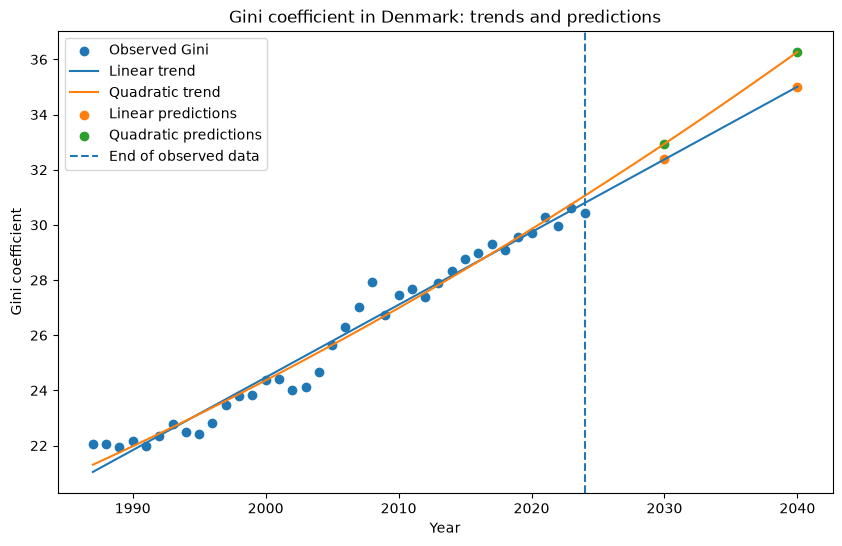

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

# Historical data
ax.scatter(
    gini['year'],
    gini['gini'],
    label='Observed Gini'
)

# Linear trend
ax.plot(
    years_prediction,
    linear_prediction,
    label='Linear trend'
)

# Quadratic trend
ax.plot(
    years_prediction,
    quadratic_prediction,
    label='Quadratic trend'
)

# Predictions for 2030 and 2040
ax.scatter(
    [2030, 2040],
    [gini_2030_linear, gini_2040_linear],
    label='Linear predictions'
)

ax.scatter(
    [2030, 2040],
    [gini_2030_quadratic, gini_2040_quadratic],
    label='Quadratic predictions'
)

ax.axvline(
    gini['year'].max(),
    linestyle='--',
    label='End of observed data'
)

ax.set_title('Gini coefficient in Denmark: trends and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()

plt.show()

Discussions about the predictions:

We calculate the models fitted values:

In [61]:
gini['linear_fit'] = (
    beta_linear[0]
    + beta_linear[1] * t
)

gini['quadratic_fit'] = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)

We calulate SSE (the sum of squared errors). The lower the better:

$$
SSE = \sum_i (y_i - \hat{y}_i)^2
$$

In [62]:
sse_linear = np.sum(
    (gini['gini'] - gini['linear_fit'])**2
)

sse_quadratic = np.sum(
    (gini['gini'] - gini['quadratic_fit'])**2
)

print('Linear SSE:', sse_linear)
print('Quadratic SSE:', sse_quadratic)

Linear SSE: 9.589130386260248
Quadratic SSE: 8.980711741455234


We calulate R-squared values (the higher the better)

In [63]:
sst = np.sum(
    (gini['gini'] - gini['gini'].mean())**2
)

r2_linear = 1 - sse_linear / sst
r2_quadratic = 1 - sse_quadratic / sst

print('Linear R-squared:', r2_linear)
print('Quadratic R-squared:', r2_quadratic)

Linear R-squared: 0.9706735862731656
Quadratic R-squared: 0.9725343115087133


We gather the result in a figure:

In [64]:
results = pd.DataFrame({
    'Model': ['Linear', 'Quadratic'],
    'Gini 2030': [
        gini_2030_linear,
        gini_2030_quadratic
    ],
    'Gini 2040': [
        gini_2040_linear,
        gini_2040_quadratic
    ],
    'SSE': [
        sse_linear,
        sse_quadratic
    ],
    'R-squared': [
        r2_linear,
        r2_quadratic
    ]
})

results

,Model,Gini 2030,Gini 2040,SSE,R-squared
0,Linear,32.375386,35.010882,9.589130,0.970674
1,Quadratic,32.940659,36.270974,8.980712,0.972534


The linear and quadratic trends both capture the general increase in the Danish Gini coefficient over the historical period. The quadratic model fits the historical observations somewhat better, as indicated by its lower sum of squared errors and higher R-squared. This is expected because the quadratic model is more flexible and has an additional parameter.

However, the predictions from the two models become increasingly different as we extrapolate further into the future, particularly towards 2040. The quadratic specification is sensitive to the estimated curvature, meaning that even a relatively small quadratic coefficient can have a large effect when t becomes large.

Therefore, the predictions should be interpreted with caution. These models assume that the historical trend will continue in the future and do not account for changes in taxation, transfers, labour markets, economic crises or other factors affecting inequality. The linear model is simpler and may therefore be more conservative for long-run extrapolation, while the quadratic model may fit the historical data better but can produce less reliable long-term forecasts.